In [2]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from random import random, randint
from collections import Counter, namedtuple
from math import hypot
from abc import ABC, abstractmethod

In [3]:
class Vector:
    """ A vector stores information and operations regarding the 
        direction and speed of motion.
    
        Parameters:
            vx (int or float):  x component of Vector.
            vy (int or float):  y component of Vector.
        Properties:
            mag (int or float): get/set magnitude of Vector.
            unit (Vector):      Get unit vector of Vector.
    """

    def __init__(self, vx, vy):
        self.vx = vx
        self.vy = vy
    @property
    def mag(self):
        """ Get the magnitude of the vector."""
        return hypot(self.vx, self.vy)
    @mag.setter
    def mag(self, mag):
        """ Set the vector to the specified magnitude, maintaining its direction."""
        scalar = mag / self.mag
        self.vx = self.vx * scalar
        self.vy = self.vy * scalar
    @property
    def unit(self):
        """ Get the unit vector of the vector."""
        mag = self.mag
        return Vector(self.vx / mag, self.vy / mag)

    def __repr__(self):
        return f"Vector({self.vx!r}, {self.vy!r})"

    def __bool__(self):
        """ Check truthiness of vector."""
        return bool(abs(self))

    def __add__(self, other):
        """ Add two vectors."""
        vx = self.vx + other.vx
        vy = self.vy + other.vy
        return Vector(vx, vy)

    def __sub__(self, other):
        """ Subtract two vectors."""
        return self + Vector(-other.vx, other.vy)

    def __mul__(self, other):
        """ Scale the vector up if float or int, calculate dot product if Vector."""
        if type(other) == type(self):
            return self.vx * other.vx + self.vy * other.vy
        return Vector(self.vx * other, self.vy * other)
    
    def __rmul__(self, other):
        """ Called if int or float * Vector."""
        return self.__mul__(other)

    def __truediv__(self, scalar):
        """ Scale the vector down if float or int."""
        return Vector(self.vx / scalar, self.vy / scalar)

    @staticmethod
    def generate(mag):
        vector = Vector(random() - 0.5, random() - 0.5)
        vector.mag = mag
        return vector
        
        

In [4]:
Entities = namedtuple("Entities", ["population", "food"])

def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""
    return random() <= chance

def distance(source, other):
    """ Returns the distance between two Entity objects."""
    dx = source.x - other.x
    dy = source.y - other.y
    return hypot(dx, dy)

def collision(source, target):
    """ Detect whether two round objects are touching."""
    if distance(source, target) <= source.radius + target.radius:
        return True
    return False

def resolve_collision(source, target):
    """ Test
    """
    source.motion, target.motion = target.motion, source.motion


class Extent():
    """ The rectangular extent of a habitat"""

    def __init__(self, width, height):
        self.width = width
        self.height = height
    
    def contains(self, entity):
        """ Check whether entity is contained completely within bounds of extent"""
        return (entity.x <= (self.width - entity.radius) and entity.x >= (0 + entity.radius) and
                entity.y <= (self.height - entity.radius) and entity.y >= (0 + entity.radius))


class Entity(ABC):
    """ Abstract base class for entities. An entity is any interactable object in 
        the Environment that has location (x, y) and radius.
    """

    def __init__(self, x, y, radius):
        self.x = x
        self.y = y
        self.radius = radius
        self.patch = plt.Circle((x, y), radius) # matplotlib patch
    
    def __iadd__(self, vector):
        """  Update the location of self by Vector ."""
        self.x = self.x + vector.vx
        self.y = self.y + vector.vy
        return self
    
    @staticmethod
    @abstractmethod
    def spawn(extent):
        """ Every child of Entity must have a static spawn method."""
        pass


class Organism(Entity):
    """ The Organism object represents a live entity.

        Parameters:
            x (int or float):                   x location of Organism.
            y (int or float):                   y location of Organism.
            radius (float):                     the radius of the Organism.
            motion (Vector):                    the speed and direction of Organism.
        Attributes:
            period (int):                       the current age of Organism.
            energy (int or float):              the amount of energy stored by Organism.      
            patch (matplotlib.patches.Circle):  patch for visualization on plot.
    """
    
    def __init__(self, x, y, radius = .25, motion = Vector(0, 0)):
        super().__init__(x, y, radius)
        self.motion = motion
        self.energy = 2
        self.period = 0

    def __str__(self):
        return f"Organism < age: {self.period!r}, location({self.x!r}, {self.y!r})>"
    
    def __repr__(self):
        return f"{self.period!r}"
    
    def __call__(self):
        """ advance the entity by one period."""
        self += self.motion
        self.period += 1
        self.patch.center = (self.x, self.y)
        return self

    def spawn(extent):
        return Organism(
            x=random() * extent.width,
            y=random() * extent.height,
            motion=Vector.generate(0.2)
        )


class Food(Entity):
    """ The Food object provides energy for a live
        entity. This food object is stationary.

        Parameters:
            x (int or float):                   x location of Food.
            y (int or float):                   y location of Food.
            energy (float):                     The energy value of Food.
        Attributes:
            patch (matplotlib.patches.Circle):  patch for visualization on plot.
    """

    def __init__(self, x, y, radius = .1, energy = 1):
        super().__init__(x, y, radius)
        self.energy = energy
        self.patch.set_color("green")
    
    def __repr__(self):
        return f"Food <energy: {self.energy!r}, location({self.x!r}, {self.y!r})>"

    def spawn(extent):
        return Food(
            x=random() * extent.width,
            y=random() * extent.height
        )


class Environment():
    """ The environment tracks the population and parameters of the simulation.

        Parameters:
            repro_chance (float):               Chance of reproduction
            death_chance (float):               Chance of death
            starting_pop (int):                 Starting population
            extent (iterable [width, height]):  Extent of habitat
        
        TODO: Explain remaining attributes once fully established.
    """

    def __init__(self, repro_chance, death_chance, starting_pop, starting_food, food_rate, extent):
        # Simulation arguments
        self.repro_chance = repro_chance
        self.death_chance = death_chance
        self.starting_pop = starting_pop
        self.starting_food = starting_food
        self.food_rate = food_rate
        self.extent = Extent(*extent)
        # Hard simluation parameters
        self.period_length = 25
        # Simulation data
        self.ents = Entities(population=[], food=[]) #Currently existing entities
        for i in range(0, self.starting_pop):
            self.ents.population.append(self.spawn(Organism))
        for i in range(0, self.starting_food):
            self.ents.food.append(self.spawn(Food))
        self.history = [starting_pop]
        self.mortuary = Counter()
        # Plot attributes
        self._fig, self._ax = plt.subplots(1, 1)
        self._ax.set_xlim(0, self.extent.width)     #Set habitat plane x size
        self._ax.set_ylim(0, self.extent.height)    #Set habitat plane y size
        self._ax.set_aspect('equal')                #Make sure x and y scales equal

    def __repr__(self):
        return f"Environment <population: {self.ents.population!r}, extent: {self.extent!r}>"

    def __call__(self):
        """ Advance the simulation by one frame."""
        # Simulate period
        # survive, expire, births = [], [], []

        # Update organism motion
        resolved = []
        print("Next Round")
        for organism in self.ents.population:
            # Organism collides with extent boundary
            if organism.x >= (self.extent.width - organism.radius) or organism.x <= (0 + organism.radius):
                organism.motion.vx = -organism.motion.vx
            if organism.y >= (self.extent.height - organism.radius) or organism.y <= (0 + organism.radius):
                organism.motion.vy = -organism.motion.vy
            # organism collides with other organsim
            target = next( (target for target in self.ents.population if target is not organism and collision(organism, target)), None)
            if target and target not in resolved:
                print(id(organism))
                resolve_collision(organism, target)
                resolved.append(target)
            organism()

            
        # # Finally, update attributes
        # self.ents.population = survive + births
        # self.mortuary.update(expire)
        # self.history.append(len(self.population))

    def fig_init(self):
        for group in self.ents:
            for ent in group:
                self._ax.add_patch(ent.patch)
        
    def fig_animate(self, frame):
        self() #Advance simulation by one frame

    def run(self, n_period):
        plt.rcParams["animation.html"] = "jshtml"
        return animation.FuncAnimation(self._fig, self.fig_animate, init_func=self.fig_init, frames=n_period)


        ##TODO
        ##PSEUDOCODE##
        """ 
            for each iteration in range(0, n_iterations):  #how many iterations to simulate total  
                for each interval range(0, interval_size):
                    for each cell in population:
                        Cell moves and gathers food
                            if cell energy <= 0:
                                cell stops moving
                    Update graphic
                -Evaluate cell success after interval-
                for each cell in population:
                    if cell energy <= 0:
                        remove cell from population and add to mortuary
                    if cell energy >= repro_energy_requirement:
                        add new cell to population, offset from original cell
                
                Update population line graph
                Update popualtion expiration histogram
        """

    def spawn(self, entity):
        while True:
            ent = entity.spawn(self.extent)
            # Must spawn inside of habitat and must not overlap with others
            if self.extent.contains(ent):
                if not any(collision(ent, target) for group in self.ents for target in group):
                    return ent                
        


In [5]:
v1 = Vector.generate(2)
v2 = Vector.generate(4)


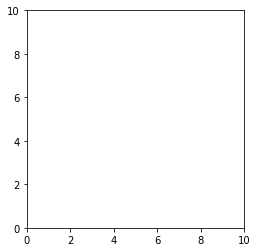

In [6]:
try:
    del env
except Exception:
    pass
env = Environment(.1, .1, 10, 20, 20, (10, 10))


In [7]:
env.run(100)                                                                     

Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
2437618966712
Next Round
Next Round
Next Round
Next Round
Next Round
2437618967384
Next Round
Next Round
Next Round
Next Round
Next Round
2437618777056
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
2437618967384
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
2437618967384
Next Round
Next Round
2437618968056
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
2437618776664
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
Next Round
2437618693680
Next Round
Next Rou

In [119]:
resolved = env.ents.population[0:9:2]
print(resolved)
x = env.ents.population[4]

x in resolved

[100, 100, 100, 100, 100]


True